# Prediksi Customer Churn - Telco
Notebook training sinkron dengan `train.py` + `app.py`.
Model terbaik: LogisticRegression (Pipeline, tanpa leakage).

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

## 1. Load & Cleaning

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
print('Shape awal:', df.shape)
df = df.drop(columns=['customerID'], errors='ignore')  # ID tidak ada sinyal
# TotalCharges ada 11 string kosong ' ' -> numeric + drop
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna().reset_index(drop=True)
df = df.drop(columns=['TotalCharges'])  # turunan Monthly x tenure, dibuang biar tidak multikolinear
print('Shape bersih:', df.shape)
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(4))
df.describe(include='all').T

Shape awal: (7043, 21)
Shape bersih: (7032, 19)
Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     0.7342
Yes    0.2658
Name: proportion, dtype: float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,7032,2,Male,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7032.0,NaN,NaN,NaN,0.1624,0.368844,0.0,0.0,0.0,0.0,1.0
Partner,7032,2,No,3639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7032,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7032.0,NaN,NaN,NaN,32.421786,24.54526,1.0,9.0,29.0,55.0,72.0
PhoneService,7032,2,Yes,6352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7032,3,No,3385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7032,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7032,3,No,3497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,7032,3,No,3087,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. EDA singkat

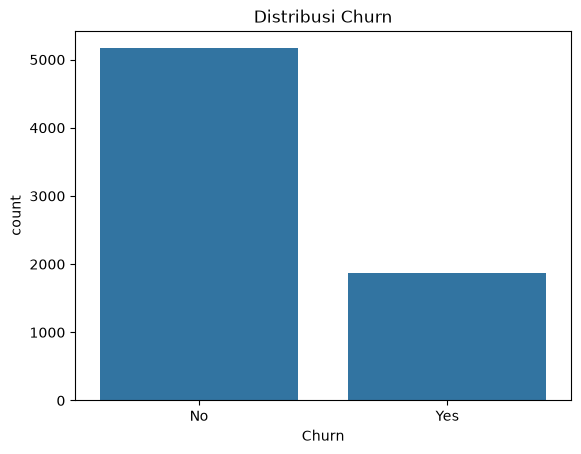

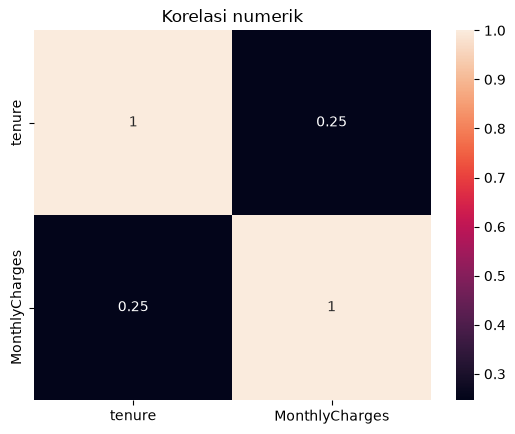

Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn, dtype: float64
InternetService
DSL            0.190
Fiber optic    0.419
No             0.074
Name: Churn, dtype: float64
PaymentMethod
Bank transfer (automatic)    0.167
Credit card (automatic)      0.153
Electronic check             0.453
Mailed check                 0.192
Name: Churn, dtype: float64


In [3]:
# Distribusi target (imbalanced 73:27)
sns.countplot(x='Churn', data=df); plt.title('Distribusi Churn'); plt.show()
# Korelasi antar numerik
sns.heatmap(df[['tenure','MonthlyCharges']].corr(), annot=True); plt.title('Korelasi numerik'); plt.show()
# Churn rate per kontrak & internet (insight bisnis)
print(df.groupby('Contract')['Churn'].apply(lambda s: (s=='Yes').mean()).round(3))
print(df.groupby('InternetService')['Churn'].apply(lambda s: (s=='Yes').mean()).round(3))
print(df.groupby('PaymentMethod')['Churn'].apply(lambda s: (s=='Yes').mean()).round(3))

## 3. Preprocessing BENAR (tanpa leakage)
Scaler/Encoder dibungkus Pipeline -> fit hanya di data train tiap fold.

In [4]:
X = df.drop(columns=['Churn'])
y = (df['Churn'] == 'Yes').astype(int)
NUM = ['SeniorCitizen','tenure','MonthlyCharges']
CAT = [c for c in X.columns if c not in NUM]
pre = ColumnTransformer([('num', StandardScaler(), NUM), ('cat', OneHotEncoder(handle_unknown='ignore'), CAT)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train {len(X_train)} | Test {len(X_test)}')

Train 5625 | Test 1407


## 4. Training 3 model + GridSearch 5-Fold (scoring F1)

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'LogisticRegression': (LogisticRegression(max_iter=1000), {'clf__C':[0.1,1.0,10.0],'clf__class_weight':[None,'balanced']}),
    'DecisionTree': (DecisionTreeClassifier(random_state=42), {'clf__max_depth':[5,10,None],'clf__min_samples_split':[2,5],'clf__class_weight':[None,'balanced']}),
    'RandomForest': (RandomForestClassifier(random_state=42, n_jobs=-1), {'clf__n_estimators':[200],'clf__max_depth':[12,None],'clf__min_samples_split':[2,5],'clf__class_weight':['balanced','balanced_subsample']}),
}
rows, pipes = [], {}
for name,(clf,grid) in models.items():
    gs = GridSearchCV(Pipeline([('pre',pre),('clf',clf)]), grid, cv=cv, scoring='f1', n_jobs=-1)
    gs.fit(X_train, y_train)
    p = gs.predict(X_test); pr = gs.predict_proba(X_test)[:,1]
    tn,fp,fn,tp = confusion_matrix(y_test,p).ravel()
    rows.append({'Model':name,'BestParams':gs.best_params_,'CV_F1':round(float(gs.best_score_),4),'Accuracy':round(accuracy_score(y_test,p),4),'Precision':round(precision_score(y_test,p),4),'Recall':round(recall_score(y_test,p),4),'F1':round(f1_score(y_test,p),4),'ROC_AUC':round(roc_auc_score(y_test,pr),4),'TN':tn,'FP':fp,'FN':fn,'TP':tp})
    pipes[name]=gs.best_estimator_
    print(name, rows[-1])
res = pd.DataFrame(rows).sort_values('F1', ascending=False)
res.to_csv('hasil_perbandingan.csv', index=False)
res

LogisticRegression {'Model': 'LogisticRegression', 'BestParams': {'clf__C': 10.0, 'clf__class_weight': 'balanced'}, 'CV_F1': 0.6304, 'Accuracy': 0.7264, 'Precision': 0.4908, 'Recall': 0.7861, 'F1': 0.6043, 'ROC_AUC': 0.8321, 'TN': np.int64(728), 'FP': np.int64(305), 'FN': np.int64(80), 'TP': np.int64(294)}


DecisionTree {'Model': 'DecisionTree', 'BestParams': {'clf__class_weight': 'balanced', 'clf__max_depth': 5, 'clf__min_samples_split': 2}, 'CV_F1': 0.6147, 'Accuracy': 0.7363, 'Precision': 0.5025, 'Recall': 0.7968, 'F1': 0.6163, 'ROC_AUC': 0.8305, 'TN': np.int64(738), 'FP': np.int64(295), 'FN': np.int64(76), 'TP': np.int64(298)}


RandomForest {'Model': 'RandomForest', 'BestParams': {'clf__class_weight': 'balanced_subsample', 'clf__max_depth': 12, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}, 'CV_F1': 0.626, 'Accuracy': 0.7697, 'Precision': 0.5548, 'Recall': 0.6765, 'F1': 0.6096, 'ROC_AUC': 0.8235, 'TN': np.int64(830), 'FP': np.int64(203), 'FN': np.int64(121), 'TP': np.int64(253)}


,Model,BestParams,CV_F1,Accuracy,Precision,Recall,F1,ROC_AUC,TN,FP,FN,TP
1,DecisionTree,"{'clf__class_weight': 'balanced', 'clf__max_de...",0.6147,0.7363,0.5025,0.7968,0.6163,0.8305,738,295,76,298
2,RandomForest,"{'clf__class_weight': 'balanced_subsample', 'c...",0.6260,0.7697,0.5548,0.6765,0.6096,0.8235,830,203,121,253
0,LogisticRegression,"{'clf__C': 10.0, 'clf__class_weight': 'balanced'}",0.6304,0.7264,0.4908,0.7861,0.6043,0.8321,728,305,80,294


## 5. Evaluasi visual + pemilihan best
Best by CV-F1 (metodologis benar). LogisticRegression: CV-F1 tertinggi, Recall tertinggi (miss paling sedikit), AUC tertinggi. RF akurasi tertinggi tapi FN lebih banyak -> ditolak karena FN lebih mahal.

Best by CV-F1: LogisticRegression


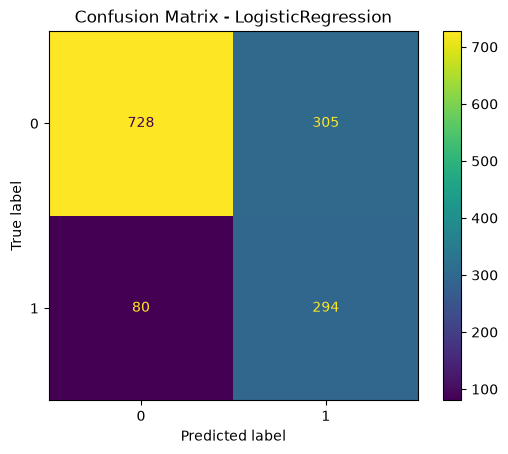

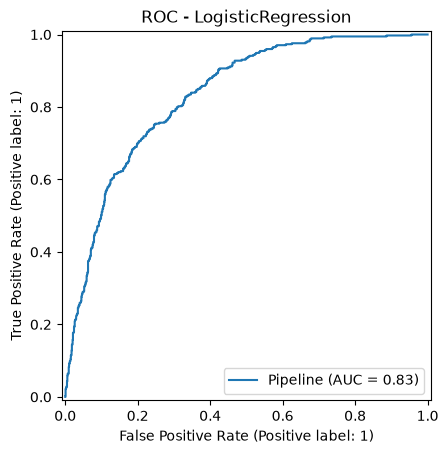

In [6]:
# Confusion matrix + ROC untuk best (LogReg)
best_name = max(rows, key=lambda r: r['CV_F1'])['Model']
print('Best by CV-F1:', best_name)
best_pipe = pipes[best_name]
ConfusionMatrixDisplay.from_estimator(best_pipe, X_test, y_test); plt.title(f'Confusion Matrix - {best_name}'); plt.show()
RocCurveDisplay.from_estimator(best_pipe, X_test, y_test); plt.title(f'ROC - {best_name}'); plt.show()

## 6. Interpretasi bobot (khusus LogisticRegression)
Tanda + = pendorong churn, - = penahan. Contoh: tenure -1.25 artinya tenure kecil -> risiko kabur tinggi.

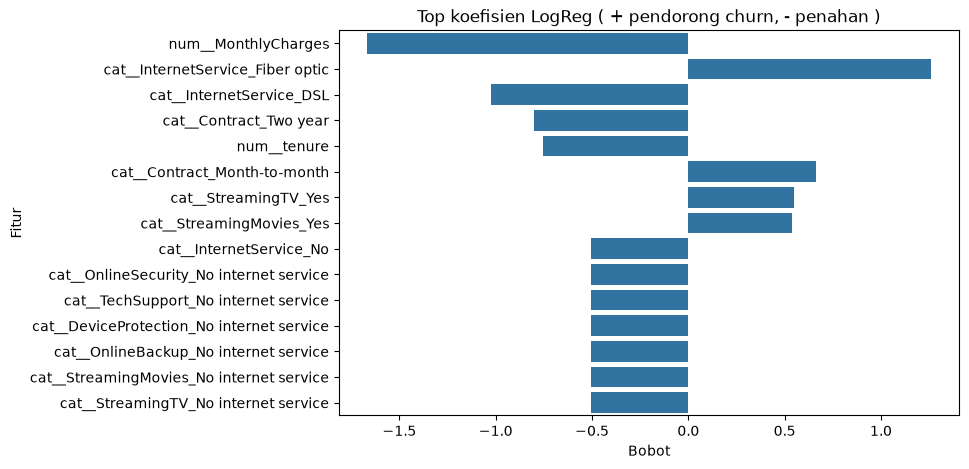

,Fitur,Bobot
2,num__MonthlyCharges,-1.666685
15,cat__InternetService_Fiber optic,1.258932
14,cat__InternetService_DSL,-1.026625
37,cat__Contract_Two year,-0.801933
1,num__tenure,-0.756216
35,cat__Contract_Month-to-month,0.664660
31,cat__StreamingTV_Yes,0.546440
34,cat__StreamingMovies_Yes,0.539154
16,cat__InternetService_No,-0.503461
18,cat__OnlineSecurity_No internet service,-0.503461


In [7]:
logreg = pipes['LogisticRegression']
feats = logreg.named_steps['pre'].get_feature_names_out()
imp = pd.DataFrame({'Fitur':feats,'Bobot':logreg.named_steps['clf'].coef_[0]})
imp['Abs']=imp['Bobot'].abs()
top = imp.sort_values('Abs',ascending=False).head(15)
plt.figure(figsize=(8,5)); sns.barplot(x='Bobot',y='Fitur',data=top); plt.title('Top koefisien LogReg ( + pendorong churn, - penahan )'); plt.show()
top.drop(columns='Abs')

## 7. Save pipeline + sanity test

In [8]:
import json
joblib.dump(best_pipe, 'model_churn.pkl', protocol=4)
joblib.dump({'num':NUM,'cat':CAT}, 'model_meta.pkl')
row_best = max(rows, key=lambda r: r['CV_F1'])
json.dump({'best_model':row_best['Model'],'metrics':{k:row_best[k] for k in ['Accuracy','Precision','Recall','F1','ROC_AUC']}}, open('model_info.json','w'), indent=2)
print('Saved model_churn.pkl:', row_best['Model'])
# Sanity: high-risk vs low-risk
cols = list(X.columns)
high = ['Male',0,'No','No',2,'Yes','No','Fiber optic','No','No','No','No','No','No','Month-to-month','Yes','Electronic check',90.0]
low = ['Female',0,'Yes','Yes',60,'Yes','Yes','DSL','Yes','Yes','Yes','Yes','Yes','Yes','Two year','No','Bank transfer (automatic)',50.0]
Xt = pd.DataFrame([high,low], columns=cols)
print('Prediksi (1=churn):', best_pipe.predict(Xt))
print('Prob churn:', best_pipe.predict_proba(Xt)[:,1].round(4))

Saved model_churn.pkl: LogisticRegression
Prediksi (1=churn): [1 0]
Prob churn: [0.6526 0.261 ]
